In [ ]:
!pip install xgboost

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
import kagglehub

# Downloading dataset
path = kagglehub.dataset_download("talhanazir168/store-inventory-demand-forecasting-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'store-inventory-demand-forecasting-dataset' dataset.
Path to dataset files: /kaggle/input/store-inventory-demand-forecasting-dataset


In [ ]:


train = pd.read_csv('/root/.cache/kagglehub/datasets/talhanazir168/store-inventory-demand-forecasting-dataset/versions/1/train.csv', parse_dates=['date'])
test  = pd.read_csv('/root/.cache/kagglehub/datasets/talhanazir168/store-inventory-demand-forecasting-dataset/versions/1/test.csv',  parse_dates=['date'])


In [ ]:
test.to_csv("forecasted_test.csv", index=False)

In [ ]:
# 3. Basic date features + weekend flag
def create_date_features(df):
    df['day']       = df['date'].dt.day
    df['month']     = df['date'].dt.month
    df['year']      = df['date'].dt.year
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend']= df['dayofweek'].isin([5,6]).astype(int)
    return df

train = create_date_features(train)
test  = create_date_features(test)

In [ ]:
# 4. Build aggregates
store_avg      = train.groupby('store')['sales'].mean().rename('store_avg')
item_avg       = train.groupby('item') ['sales'].mean().rename('item_avg')
store_item_avg = train.groupby(['store','item'])['sales'].mean().rename('store_item_avg')

dow_avg        = train.groupby('dayofweek')['sales'].mean().rename('dow_avg')
month_avg      = train.groupby('month')    ['sales'].mean().rename('month_avg')
store_dow_avg  = train.groupby(['store','dayofweek'])['sales'].mean().rename('store_dow_avg')
item_dow_avg   = train.groupby(['item','dayofweek']) ['sales'].mean().rename('item_dow_avg')

In [ ]:
def merge_aggs(df):
    df['store_avg']      = df['store'].map(store_avg)
    df['item_avg']       = df['item'].map(item_avg)
    df['store_item_avg'] = df.set_index(['store','item']).index.map(store_item_avg)
    df['dow_avg']        = df['dayofweek'].map(dow_avg)
    df['month_avg']      = df['month'].map(month_avg)
    df['store_dow_avg']  = df.set_index(['store','dayofweek']).index.map(store_dow_avg)
    df['item_dow_avg']   = df.set_index(['item','dayofweek']).index.map(item_dow_avg)
    return df

train = merge_aggs(train)
test  = merge_aggs(test)

In [ ]:
# 5. Prepare modeling sets
X = train.drop(columns=['date','sales'])
y = train['sales']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1,
    verbose=1
)

In [ ]:
search.fit(X_train, y_train)
best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# 7. Validation performance
y_pred   = best_model.predict(X_val)
rmse     = sqrt(mean_squared_error(y_val, y_pred))
mape_val = np.mean(np.abs((y_val.values - y_pred) /
                          np.maximum(y_val.values,1))) * 100
accuracy = 100 - mape_val

In [ ]:
print("Enhanced XGBoost Results")
print(f"  • RMSE:     {rmse:.2f}")
print(f"  • MAPE:     {mape_val:.2f}%")
print(f"  • Accuracy: {accuracy:.2f}%")

Enhanced XGBoost Results
  • RMSE:     7.25
  • MAPE:     13.11%
  • Accuracy: 86.89%


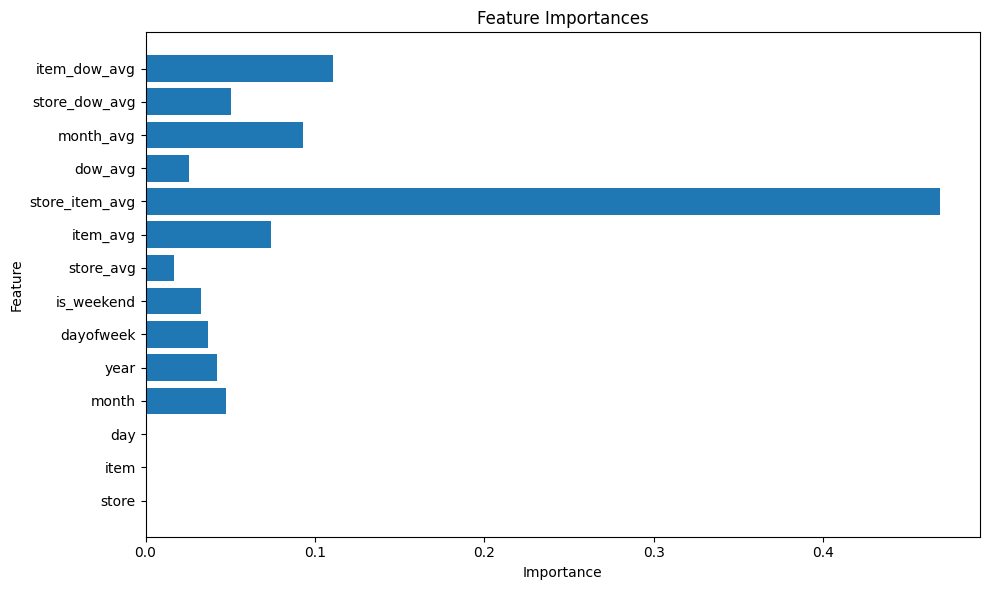

In [ ]:
# 8. Plot 1: Feature importances
plt.figure(figsize=(10,6))
plt.barh(X.columns, best_model.feature_importances_)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Feature_Importances.png", dpi=300)
plt.show()

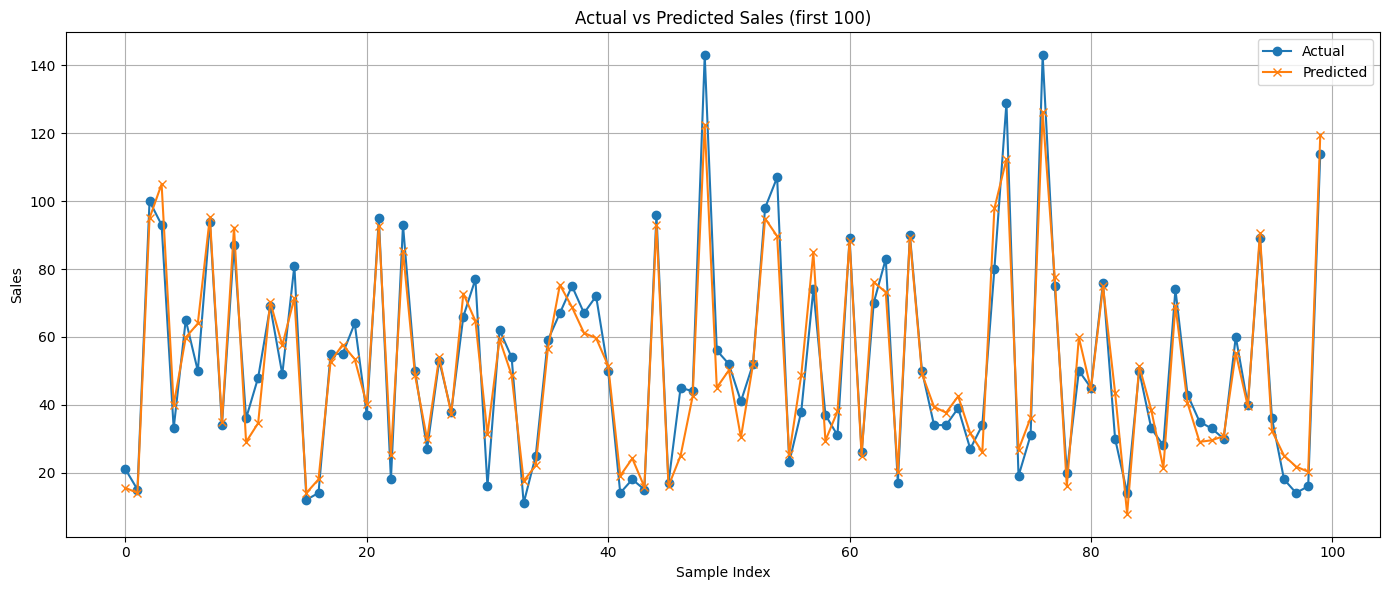

In [ ]:
# 9. Plot 2: Actual vs Predicted (first 100 samples)
plt.figure(figsize=(14,6))
plt.plot(y_val.values[:100],   label='Actual',   marker='o')
plt.plot(y_pred[:100],          label='Predicted',marker='x')
plt.title("Actual vs Predicted Sales (first 100)")
plt.xlabel("Sample Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Actual_vs_Predicted Sales.png", dpi=300)
plt.show()

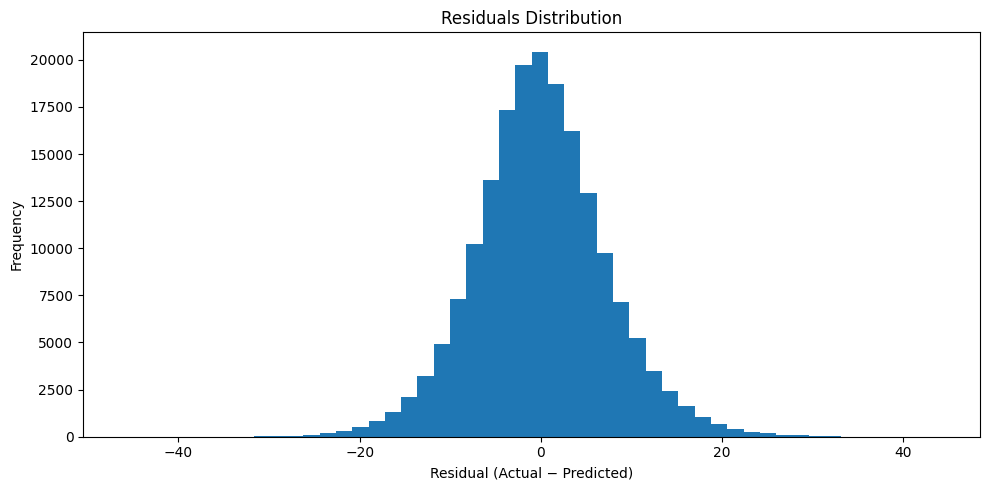

In [ ]:
# 10. Plot 3: Residuals distribution
res = y_val.values - y_pred
plt.figure(figsize=(10,5))
plt.hist(res, bins=50)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Residuals_Distribution.png", dpi=300)
plt.show()

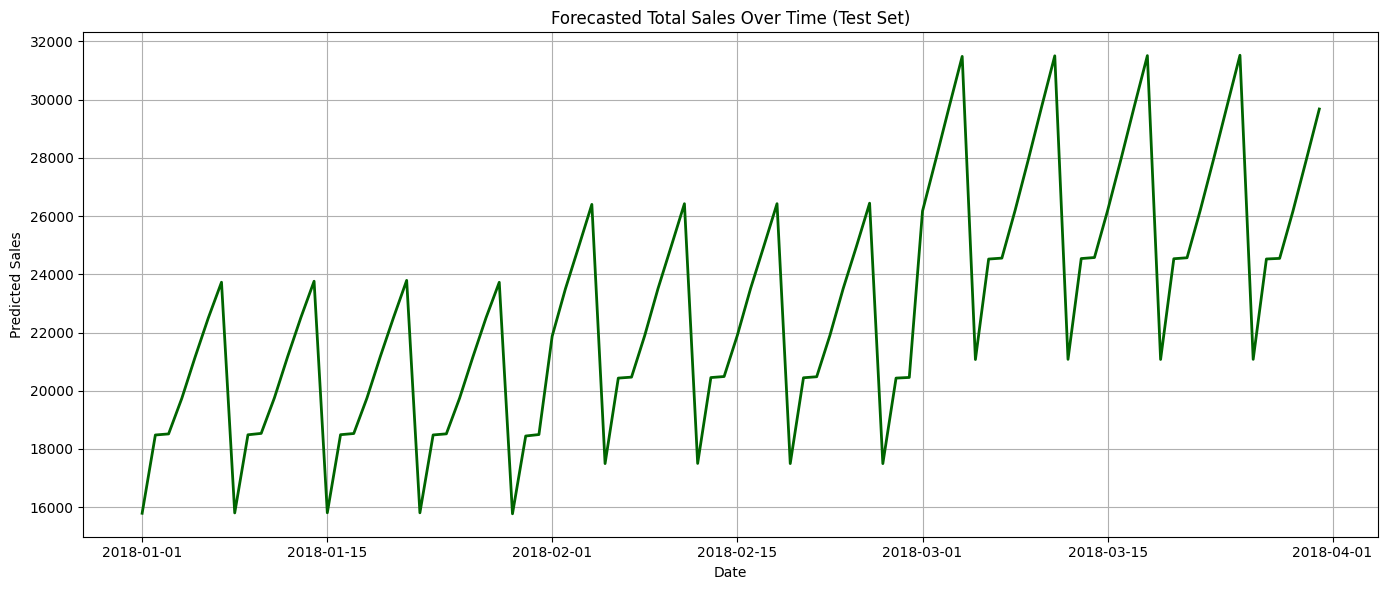

In [ ]:
tf = test.drop(columns=['date', 'id', 'predicted_sales'], errors='ignore')
test = test.drop(columns=['predicted_sales'], errors='ignore')
test['predicted_sales'] = best_model.predict(tf)


ts = test.groupby('date')['predicted_sales'].sum()

plt.figure(figsize=(14,6))
plt.plot(ts.index, ts.values, color='darkgreen', linewidth=2)
plt.title("Forecasted Total Sales Over Time (Test Set)")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("Forecasted_Total_Sales_Over_Time.png", dpi=300)
plt.show()

In [ ]:
import seaborn as sns
tf = test.drop(columns=['date', 'id', 'predicted_sales'], errors='ignore').copy()
test['predicted_sales'] = best_model.predict(tf)

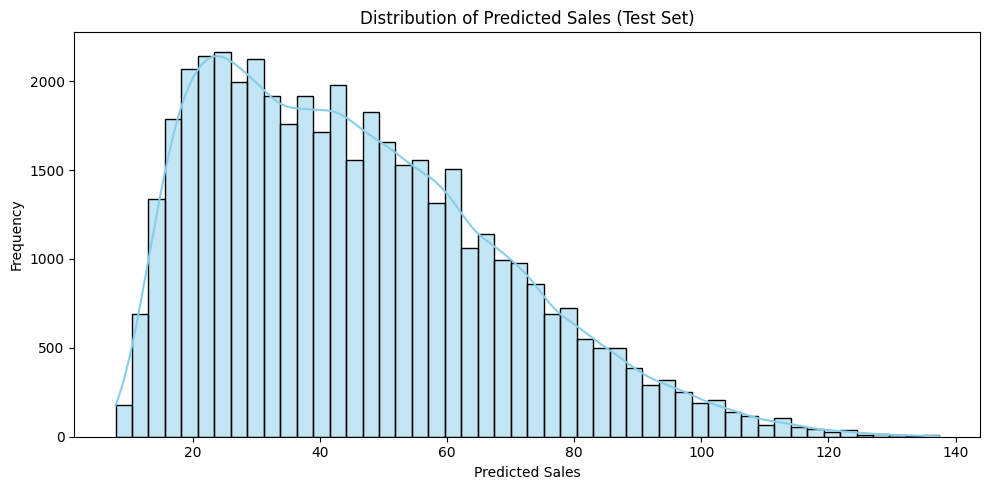

In [ ]:
#Predicted Sales Distribution
plt.figure(figsize=(10,5))
sns.histplot(test['predicted_sales'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Predicted Sales (Test Set)")
plt.xlabel("Predicted Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Distribution_of_Predicted_Sales.png", dpi=300)
plt.show()

/tmp/ipykernel_3245/2370113446.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_avg.index, y=dow_avg.values, palette="viridis")


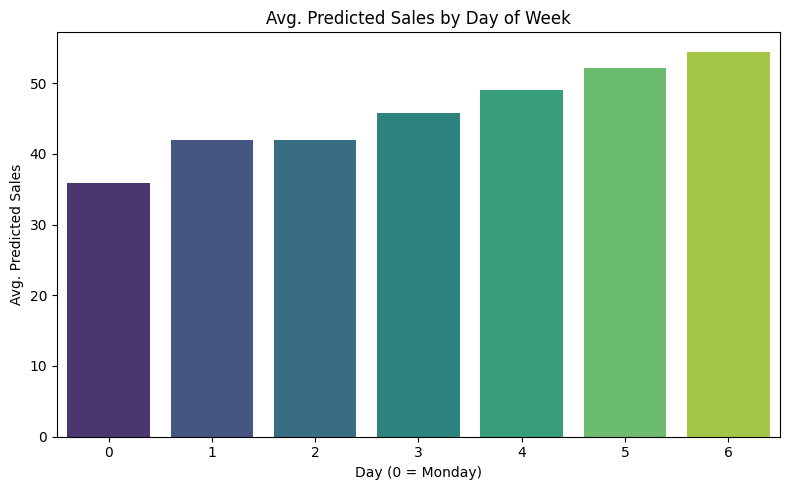

In [ ]:
#Avg Predicted Sales by Day of Week
test['dayofweek'] = test['date'].dt.dayofweek
dow_avg = test.groupby('dayofweek')['predicted_sales'].mean()
plt.figure(figsize=(8,5))
sns.barplot(x=dow_avg.index, y=dow_avg.values, palette="viridis")
plt.title("Avg. Predicted Sales by Day of Week")
plt.xlabel("Day (0 = Monday)")
plt.ylabel("Avg. Predicted Sales")
plt.tight_layout()
plt.savefig("Avg_Predicted_Sales.png", dpi=300)
plt.show()

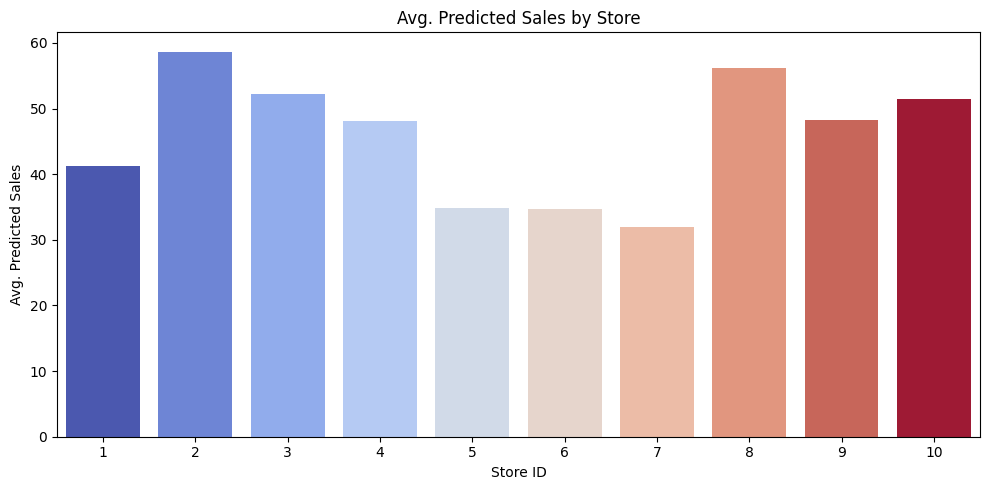

In [ ]:
# Avg Predicted Sales by Store
# Make sure 'test' has a 'predicted_sales' column
store_avg_pred = test.groupby('store')['predicted_sales'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=store_avg_pred.index, y=store_avg_pred.values,
            hue=store_avg_pred.index, palette="coolwarm", legend=False)
plt.title("Avg. Predicted Sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Avg. Predicted Sales")
plt.tight_layout()
plt.savefig("Avg_Predicted_Sales_Store.png", dpi=300)
plt.show()

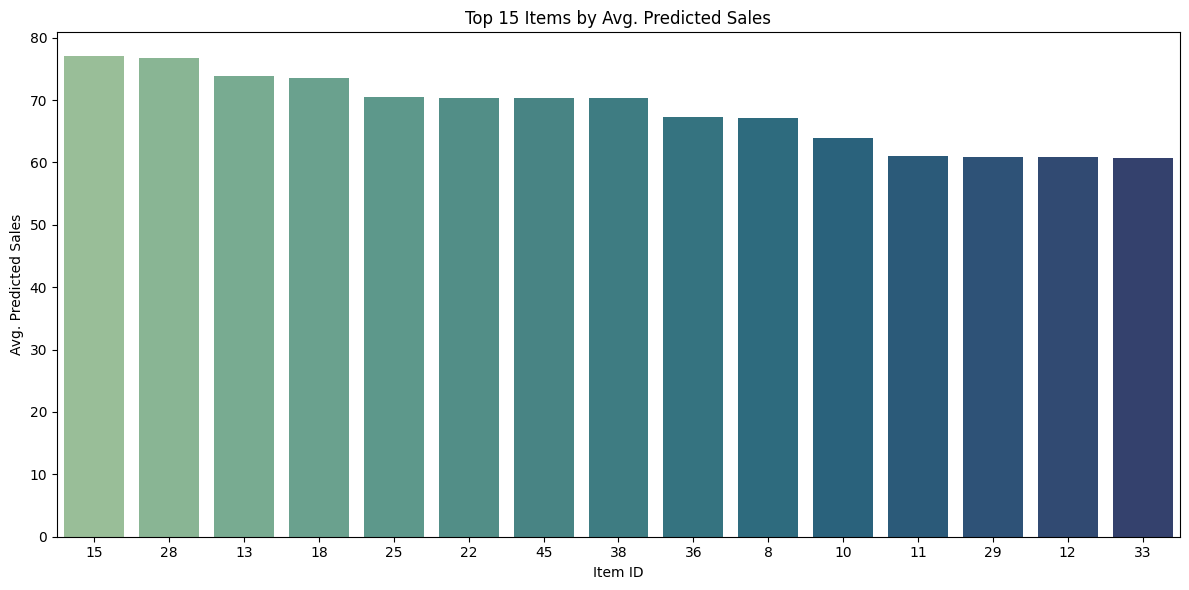

In [ ]:
#Top 15 Items with Highest Predicted Sales
item_avg_pred = test.groupby('item')['predicted_sales'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=item_avg_pred.index.astype(str), y=item_avg_pred.values,
            hue=item_avg_pred.index.astype(str), palette="crest", legend=False)
plt.title("Top 15 Items by Avg. Predicted Sales")
plt.xlabel("Item ID")
plt.ylabel("Avg. Predicted Sales")
plt.tight_layout()
plt.savefig("Top_15_Items.png", dpi=300)
plt.show()

In [ ]:
import joblib

# Saving the trained model
joblib.dump(best_model, 'xgb_sales_model.pkl')

print("Model saved as xgb_sales_model.pkl")


Model saved as xgb_sales_model.pkl


In [ ]:
import joblib

aggregates = {
    "store_avg": store_avg.to_dict(),
    "item_avg": item_avg.to_dict(),
    "store_item_avg": {str(k): v for k, v in store_item_avg.to_dict().items()},
    "dow_avg": dow_avg.to_dict(),
    "month_avg": month_avg.to_dict(),
    "store_dow_avg": {str(k): v for k, v in store_dow_avg.to_dict().items()},
    "item_dow_avg": {str(k): v for k, v in item_dow_avg.to_dict().items()},
    "global_mean": float(train["sales"].mean())
}

joblib.dump(aggregates, "aggregates.pkl")

['aggregates.pkl']

In [ ]:
from google.colab import files
files.download("aggregates.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>